## Computational Chemistry for Experimentalists
## Chapter 8: Dynamics and Conformational Sampling

Most experiments in chemistry treat ensembles of a large number (e.g., Avogadro's number) of molecules, typically undergoing some kind of thermal motion. Standard computational chemistry calculations treat single frozen conformations, one at a time. Modeling conformational dynamics and conformational ensembles can be critical for connecting computational simulations to real experiments. This set of examples illustrate ideas and pitfalls for conformational analysis.

This first block imports all of the necessary Python modules. If these aren't installed, this will fail. Ignore the warnings from the "under testing" PySCF properties modules.

In [3]:
!pip install rdkit
!pip install pyscf
!pip install py3Dmol
!pip install pyscf-properties
!pip install geometric
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from pyscf import gto,scf
from pyscf.tools import cubegen
import py3Dmol
import numpy
import matplotlib.pyplot as plt
from pyscf.geomopt.geometric_solver import optimize
from pyscf.prop import nmr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.0/79.0 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyscf-properties: filename=pyscf_properties-0.1.0-py3-none-any.whl size=156564 sha256=e50f67c91bf0da9fb9e1691a4c214b12410a8984cee6fad20ab52b3e527152d7
  Stored in directory: /root/.cache/pip/wheels/51/b8/db/ac9d8afcfc683ca45b383d9af65dc788438e5d73be317fdf57
Successfully built pyscf-properties


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.2/392.2 kB 18.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for geometric: filename=geometric-1.1.1-py3-none-any.whl size=408351 sha256=81437ad8e8e5f33b380d2473626740358ecad8d93738111f4ee42834b40494d4
  Stored in directory: /root/.cache/pip/wheels/82/fe/a4/91e2803e6eafb64e10e66e04ecae5682c90f7c55bc28201573
Successfully built geometric


/usr/local/lib/python3.13/dist-packages/pyscf/prop/efg/rhf.py:45: UserWarning: Module EFG is under testing
  warnings.warn('Module EFG is under testing')
/usr/local/lib/python3.13/dist-packages/pyscf/prop/efg/dhf.py:30: UserWarning: Module EFG is under testing
  warnings.warn('Module EFG is under testing')
/usr/local/lib/python3.13/dist-packages/pyscf/prop/zfs/uhf.py:40: UserWarning: Module ZFS is under testing
  warnings.warn('Module ZFS is under testing')
/usr/local/lib/python3.13/dist-packages/pyscf/prop/gtensor/uhf.py:43: UserWarning: Module g-tensor is under testing
  warnings.warn('Module g-tensor is under testing')
/usr/local/lib/python3.13/dist-packages/pyscf/prop/gtensor/uks.py:41: UserWarning: Module g-tensor is under testing
  warnings.warn('Module g-tensor is under testing')
/usr/local/lib/python3.13/dist-packages/pyscf/prop/hfc/uks.py:35: UserWarning: Module HFC is under testing
  warnings.warn('Module HFC is under testing')
/usr/local/lib/python3.13/dist-packages/pyscf/pr

### Example 1: Conformations in NMR shielding

Compute NMR shieldings of acetaldehyde at a single local minimum geometry. Reproducing experiment requires accounting for the dynamics of the methyl group, via rotational averaging of the methyl group proton chemical shieldings.

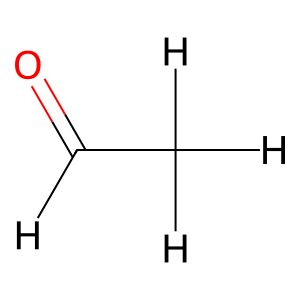

In [4]:
m=Chem.MolFromSmiles('CC=O')
m2=Chem.AddHs(m)
img=Draw.MolToImage(m2)
img

In [5]:
AllChem.EmbedMolecule(m2)
AllChem.MMFFOptimizeMolecule(m2)
elementsCO = [atom.GetSymbol() for atom in m2.GetAtoms()]
coordinates = m2.GetConformer().GetPositions()
atoms = [(element, coordinate) for element, coordinate in zip(elementsCO, coordinates)]

m3 = gto.Mole(basis="3-21g")
m3.atom = atoms
m3.build();
mf=scf.RHF(m3)
mf.kernel()
mn=nmr.RHF(mf)
BsCO=mn.kernel()
print('Atom types',elementsCO)
print(BsCO.shape)

converged SCF energy = -152.054059480518

total shielding of atom 0 C
B_x [209.50715193  17.74307629   4.47539001]
B_y [  6.30732344 168.16180562  -2.35436531]
B_z [  1.63398169  -2.33029424 177.11510488]
dia-magnetic contribution
B_x [ 2.61513109e+02 -4.02342452e-01 -6.45770668e-02]
B_y [  0.99930645 242.89070564  -0.44022754]
B_z [  0.28372832  -0.44317046 244.56137336]
para-magnetic contribution
B_x [-52.00595755  18.14541874   4.53996708]
B_y [  5.30801699 -74.72890002  -1.91413777]
B_z [  1.35025337  -1.88712379 -67.44626847]

total shielding of atom 1 C
B_x [-37.97045246 -52.44079486 -13.41827457]
B_y [-52.14246896 -36.8144486  -45.8081549 ]
B_z [-13.3441061  -45.80886932 135.70090718]
dia-magnetic contribution
B_x [260.91339906  -7.2192098   -1.70805613]
B_y [ -6.27206446 246.6821617    6.58413424]
B_z [ -1.47276685   6.58214877 221.76213549]
para-magnetic contribution
B_x [-298.88385152  -45.22158506  -11.71021843]
B_y [ -45.8704045  -283.49661031  -52.39228914]
B_z [-11.871339

In [6]:
print('Atom types',elementsCO)
for i in range(len(elementsCO)):
    print(numpy.trace(BsCO[i]))

Atom types ['C', 'C', 'O', 'H', 'H', 'H', 'H']
554.784062427306
60.91600612048876
-1276.2616771880976
93.56812954951606
92.43486235235096
93.5679984256879
68.0774223376985


Compute shieldings of tetra-methyl silane TMS as the reference for proton chemical shifts. See Chapter 17 for a discussion on chemical shieldings and chemical shifts.

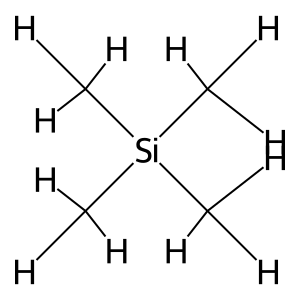

In [7]:
m5=Chem.MolFromSmiles('C[Si](C)(C)C')
m6=Chem.AddHs(m5)
img=Draw.MolToImage(m6)
img

In [8]:
AllChem.EmbedMolecule(m6)
AllChem.MMFFOptimizeMolecule(m6)
elementsTMS = [atom.GetSymbol() for atom in m6.GetAtoms()]
coordinates = m6.GetConformer().GetPositions()
atoms = [(element, coordinate) for element, coordinate in zip(elementsTMS, coordinates)]
m3 = gto.Mole(basis="3-21g")
m3.atom = atoms
m3.build();
mf=scf.RHF(m3)
mf.kernel()
mn=nmr.RHF(mf)
BsTMS=mn.kernel()

converged SCF energy = -445.043105939745

total shielding of atom 0 C
B_x [213.75540644   1.06774263   0.68450822]
B_y [  1.06775079 214.7271193    1.0634713 ]
B_z [  0.68452296   1.06347165 213.74986537]
dia-magnetic contribution
B_x [255.83827459   2.51949341   1.61517582]
B_y [  2.51956525 258.13147009   2.50958352]
B_z [  1.61524453   2.5096175  255.82556942]
para-magnetic contribution
B_x [-42.08286814  -1.45175078  -0.9306676 ]
B_y [ -1.45181446 -43.40435079  -1.44611222]
B_z [ -0.93072157  -1.44614585 -42.07570405]

total shielding of atom 1 Si
B_x [5.46155478e+02 4.13196130e-05 2.80820976e-05]
B_y [1.74558980e-05 5.46155434e+02 6.98288151e-05]
B_z [ 2.54946788e-06 -2.51537782e-05  5.46155482e+02]
dia-magnetic contribution
B_x [ 8.72799358e+02 -5.97820252e-06  1.19301092e-06]
B_y [-2.91277757e-06  8.72799381e+02 -7.35349685e-06]
B_z [ 1.48215617e-06 -4.38358095e-06  8.72799373e+02]
para-magnetic contribution
B_x [-3.26643879e+02  4.72978155e-05  2.68890867e-05]
B_y [ 2.03686756e

Compute the relative chemical shieldings of each proton in acetaldehyde from the isotropic total shieldings

In [11]:
TMSref=numpy.trace(BsTMS[6])/3
deltas=[]
print('Chemical shifts of acetaldehyde relative to TMS: %.4f'%(TMSref))
for iat in range(len(elementsCO)):
    deltas.append(0)
    if(elementsCO[iat]=='H'):
        val=numpy.trace(BsCO[iat])/3
        delta=TMSref-val
        deltas[iat]=delta
        print('%2d %2s %.3f'%(iat,elementsCO[iat],delta))

Chemical shifts of acetaldehyde relative to TMS: 33.6690
 3  H 2.480
 4  H 2.857
 5  H 2.480
 6  H 10.977


Plot the acetaldehyde optimized structure to compare the different chemical shifts

In [12]:
mb=Chem.MolToMolBlock(m2)
p=py3Dmol.view(width=400,height=400)
p.addModel(mb,'sdf')
p.setStyle({'stick':{},'sphere':{"scale":0.3}})
#p.addPropertyLabels('index',{elem:{'H'}},{fontColor:'black'})
#p.addPropertyLabels("index",{not:{elem:'H'}}, {fontColor:'black',font: 'sans-serif', fontSize: 28, showBackground:false,alignment:'center'});
#p.addPropertyLabels("atom","",{'showBackground':'false','alignment': 'center'})
p.addPropertyLabels("index","",{'showBackground':'false','alignment': 'center'})
p.zoomTo()
p.render()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The in-plane methyl proton 4 has a chemical shift different from the out-of-plane methyl protons 3 and 5. To reproduce an experiment near room temperature, we need to average the three chemical shifts to account for the dynamics of fast methyl rotation.

## Example 2: Reaction Energies

Choosing reasonable conformations of reactants and products can be essential for computing accurate reaction energies. Here we consider a simple example, the gas-phase proton affinity of ethylenediamine en. Choosing different conformations for the reactant or product of the protonation reaction can dramatically change the predicted proton affinities

First we use the RDKit EmbedMultipleConfs conformational search to  compute two low-lying conformations for the neutral reactant. The lowest-energy conformation has an internal hydrogen bond, the other conformation is extended.

In [13]:
l=Chem.MolFromSmiles('NCCN')
l2=Chem.AddHs(l)
lconfs=AllChem.EmbedMultipleConfs(l2,numConfs=100)
print('Number of conformers: %d'%(len(lconfs)))
uniqueEs=[]
uniqueIDs=[]
for confid in lconfs:
    AllChem.MMFFOptimizeMolecule(l2,confId=confid)
    ff = AllChem.MMFFGetMoleculeForceField(l2, AllChem.MMFFGetMoleculeProperties(l2), confId=confid)
    E=ff.CalcEnergy()
    keep=1
    for Eold in uniqueEs:
        if((E-Eold)**2<0.1):
            keep=0
    if(keep>0):
        uniqueEs.append(E)
        uniqueIDs.append(confid)

# Sort by energy
lEs=[(x,y) for x,y in sorted(zip(uniqueEs,uniqueIDs))]
Emin=lEs[0][0]
print('Lowest energy: %.4f'%(Emin))

p = py3Dmol.view(width=600,height=200,viewergrid=(1,2))
for i in range(2):
    ss=lEs[i]
    confid=ss[1]
    E=ss[0]
    DE=(E-Emin)
    DElabel='%.2f'%(DE)
    p.addModel(Chem.MolToMolBlock(l2,confId=confid), 'sdf',viewer=(0,i))
    p.addLabel(DElabel,{'inFront':True,'fontColor':'black','backgroundColor':'white'},viewer=(0,i))
    p.setStyle({'stick':{},'sphere':{"scale":0.3}},viewer=(0,i))
p.zoomTo()
#p.update()
p.render()


Number of conformers: 100
Lowest energy: 13.4673


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Next, we use the RDKit EmbedMultipleConfs to find low-lying conformations of the protonated molecule. Again, the lowest-lying conformation has an internal hydrogen bond from the protonated amine, but now the next lowest conformation is much higher in energy.

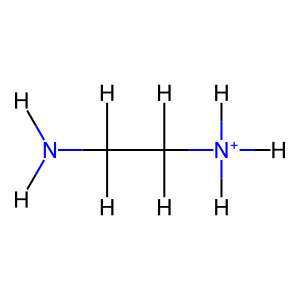

In [14]:
c=Chem.MolFromSmiles('NCC[NH3+]')
c2=Chem.AddHs(c)
img=Draw.MolToImage(c2)
img

In [15]:
cconfs=AllChem.EmbedMultipleConfs(c2,numConfs=100)
print('Number of conformers: %d'%(len(cconfs)))
uniqueEs=[]
uniqueIDs=[]
for confid in cconfs:
    AllChem.MMFFOptimizeMolecule(c2,confId=confid)
    ff = AllChem.MMFFGetMoleculeForceField(c2, AllChem.MMFFGetMoleculeProperties(c2), confId=confid)
    E=ff.CalcEnergy()
    keep=1
    for Eold in uniqueEs:
        if((E-Eold)**2<0.1):
            keep=0
    if(keep>0):
        uniqueEs.append(E)
        uniqueIDs.append(confid)

# Sort by energy
cEs=[(x,y) for x,y in sorted(zip(uniqueEs,uniqueIDs))]
Emin=cEs[0][0]
print('Lowest energy: %.4f'%(Emin))

p = py3Dmol.view(width=600,height=200,viewergrid=(1,2))
for i in range(2):
    ss=cEs[i]
    confid=ss[1]
    E=ss[0]
    DE=(E-Emin)
    DElabel='%.2f'%(DE)
    p.addModel(Chem.MolToMolBlock(c2,confId=confid), 'sdf',viewer=(0,i))
    p.addLabel(DElabel,{'inFront':True,'fontColor':'black','backgroundColor':'white'},viewer=(0,i))
    p.setStyle({'stick':{},'sphere':{"scale":0.3}},viewer=(0,i))
p.zoomTo()
#p.update()
p.render()


Number of conformers: 100
Lowest energy: 14.5679


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Next we use PySCF to compute the ground-state energies of the two low-lying reactant geometries and the two low-lying product geometries. Note that the ground state energy of the other reactant, an isolated gas-phase H+ cation, is zero.

In [16]:
le = [atom.GetSymbol() for atom in l2.GetAtoms()]
lc1 = l2.GetConformer(lEs[0][1]).GetPositions()
lc2 = l2.GetConformer(lEs[1][1]).GetPositions()
lcde=lEs[1][0]-lEs[0][0]
ac1 = [(element, coordinate) for element, coordinate in zip(le, lc1)]
ac2 = [(element, coordinate) for element, coordinate in zip(le, lc2)]

lm1 = gto.Mole(atom=ac1,basis="3-21g").build()
lm2 = gto.Mole(atom=ac2,basis="3-21g").build()

print(lEs[0][0])
lm1f=scf.RHF(lm1)
lm1f.kernel()
lm1o=optimize(lm1f)
lm1of=scf.RHF(lm1o)
lm1of.kernel()
print(lEs[1][0])
lm2f=scf.RHF(lm2)
lm2o=optimize(lm2f)
lm2of=scf.RHF(lm2o)
lm2of.kernel()
lEs2=[]
lEs2.append(lm1of.e_tot)
lEs2.append(lm2of.e_tot)
print('Reactant geometry energy difference (kcal/mol)')
print('RDKit: %.2f  PySCF: %.2f'%(lcde,627.5095*(lm2of.e_tot-lm1of.e_tot)))

13.467252019791573
converged SCF energy = -188.206329297049


geometric-optimize called with the following command line:
/usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-c2d58833-b6e7-4582-a0e1-fd41924848b5.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%%%%%,  **              ********    


Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   1.206629  -0.956858   0.210885    0.000000  0.000000  0.000000
   C   0.678635   0.393018   0.446095    0.000000  0.000000  0.000000
   C  -0.799973   0.518481   0.034274    0.000000  0.000000  0.000000
   N  -1.065967  -0.099795  -1.270811    0.000000  0.000000  0.000000
   H   2.196655  -0.966038   0.452921    0.000000  0.000000  0.000000
   H   1.172488  -1.117068  -0.797900    0.000000  0.000000  0.000000
   H   0.786758   0.648242   1.505364    0.000000  0.000000  0.000000
   H   1.279427   1.105977  -0.130390    0.000000  0.000000  0.000000
   H  -1.082817   1.575765   0.002189    0.000000 -0.000000  0.000000
   H  -1.430459   0.028586   0.785332    0.000000  0.000000  0.000000
   H  -2.063906  -0.031174  -1.466332    0.000000  0.000000  0.000000
   H  -0.877471  -1.099137  -1.169503    0.000000  0.000000  0.000000

WARN: Mole.unit (angstrom) is c

Step    0 : Gradient = 1.463e-02/2.133e-02 (rms/max) Energy = -188.2063292971
Hessian Eigenvalues: 2.30000e-02 2.30000e-02 2.30000e-02 ... 4.40210e-01 4.44620e-01 4.44621e-01



Geometry optimization cycle 2
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   1.188031  -0.944453   0.198478   -0.018598  0.012405 -0.012406
   C   0.682042   0.440729   0.414717    0.003407  0.047711 -0.031378
   C  -0.807088   0.498621   0.087448   -0.007115 -0.019861  0.053174
   N  -1.048214  -0.105855  -1.253440    0.017753 -0.006060  0.017372
   H   2.149712  -1.047880   0.489793   -0.046944 -0.081842  0.036872
   H   1.140254  -1.193936  -0.780337   -0.032235 -0.076868  0.017563
   H   0.799723   0.694221   1.458910    0.012965  0.045979 -0.046453
   H   1.200335   1.198110  -0.172383   -0.079093  0.092133 -0.041993
   H  -1.097071   1.539476   0.056225   -0.014254 -0.036289  0.054036
   H  -1.362766   0.022084   0.894339    0.067693 -0.006503  0.109008
   H  -2.009329  -0.006670  -1.548077    0.054577  0.024504 -0.081746
   H  -0.835628  -1.094447  -1.243553    0.041843  0.004690 -0.074049
converged SCF energy = -188.2122

...


Geometry optimization cycle 10
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N  -1.870548  -0.024700  -0.254107   -0.000196 -0.000139 -0.000915
   C  -0.508284  -0.561270  -0.101309    0.000011 -0.000189 -0.000482
   C   0.508284   0.561271  -0.319992   -0.000011  0.000189  0.000481
   N   1.870548   0.024699  -0.167199    0.000196  0.000139  0.000916
   H  -2.146969   0.582895   0.496737    0.000942  0.000585 -0.001063
   H  -2.569625  -0.723358  -0.426680   -0.000186 -0.000945  0.001924
   H  -0.309551  -1.018761   0.864206   -0.000778 -0.000246 -0.000461
   H  -0.361929  -1.319955  -0.861382    0.000012  0.000371 -0.000977
   H   0.361932   1.319954   0.440084   -0.000013 -0.000371  0.000975
   H   0.309549   1.018764  -1.285505    0.000779  0.000245  0.000460
   H   2.569627   0.723357   0.005372    0.000186  0.000946 -0.001923
   H   2.146966  -0.582896  -0.918044   -0.000941 -0.000585  0.001064
converged SCF energy = -188.214

Step    9 : Displace = 1.299e-03/2.135e-03 (rms/max) Trust = 3.000e-01 (=) Grad = 1.927e-05/4.306e-05 (rms/max) E (change) = -188.2149081686 (-5.656e-07) Quality = 1.079
Hessian Eigenvalues: 2.19632e-03 2.29999e-02 2.30000e-02 ... 4.43630e-01 4.44040e-01 4.48227e-01



Geometry optimization cycle 11
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N  -1.870512  -0.024799  -0.254245    0.000037 -0.000099 -0.000138
   C  -0.508241  -0.561364  -0.101441    0.000043 -0.000094 -0.000132
   C   0.508241   0.561364  -0.319860   -0.000044  0.000093  0.000131
   N   1.870512   0.024798  -0.167060   -0.000037  0.000099  0.000139
   H  -2.146708   0.583327   0.496264    0.000262  0.000431 -0.000473
   H  -2.569633  -0.723586  -0.426090   -0.000008 -0.000228  0.000590
   H  -0.309604  -1.019011   0.864016   -0.000052 -0.000251 -0.000190
   H  -0.361779  -1.319832  -0.861711    0.000150  0.000124 -0.000329
   H   0.361782   1.319831   0.440411   -0.000151 -0.000124  0.000328
   H   0.309602   1.019014  -1.285316    0.000053  0.000250  0.000189
   H   2.569634   0.723585   0.004783    0.000007  0.000228 -0.000590
   H   2.146705  -0.583327  -0.917570   -0.000261 -0.000431  0.000474
converged SCF energy = -188.214

Step   10 : Displace = 4.442e-04/6.903e-04 (rms/max) Trust = 3.000e-01 (=) Grad = 3.289e-06/5.605e-06 (rms/max) E (change) = -188.2149081865 (-1.793e-08) Quality = 0.971
Hessian Eigenvalues: 2.19632e-03 2.29999e-02 2.30000e-02 ... 4.43630e-01 4.44040e-01 4.48227e-01
Converged! =D

    #==========================================================================#
    #| If this code has benefited your research, please support us by citing: |#
    #|                                                                        |#
    #| Wang, L.-P.; Song, C.C. (2016) "Geometry optimization made simple with |#
    #| translation and rotation coordinates", J. Chem, Phys. 144, 214108.     |#
    #| http://dx.doi.org/10.1063/1.4952956                                    |#
    #==========================================================================#
    Time elapsed since start of run_optimizer: 18.966 seconds


converged SCF energy = -188.214908186497
Reactant geometry energy difference (kcal/mol)
RDKit: 0.71  PySCF: 0.26


In [17]:
ce = [atom.GetSymbol() for atom in c2.GetAtoms()]
cc1 = c2.GetConformer(cEs[0][1]).GetPositions()
cc2 = c2.GetConformer(cEs[1][1]).GetPositions()
ccde=cEs[1][0]-cEs[0][0]
ac1 = [(element, coordinate) for element, coordinate in zip(ce, cc1)]
ac2 = [(element, coordinate) for element, coordinate in zip(ce, cc2)]

cm1 = gto.Mole(atom=ac1,basis="3-21g",charge=1).build()
cm2 = gto.Mole(atom=ac2,basis="3-21g",charge=1).build()

cm1f=scf.RHF(cm1)
cm1o=optimize(cm1f)
cm1of=scf.RHF(cm1o)
cm1of.kernel()

cm2f=scf.RHF(cm2)
cm2o=optimize(cm2f)
cm2of=scf.RHF(cm2o)
cm2of.kernel()
cEs2=[]
cEs2.append(cm1of.e_tot)
cEs2.append(cm2of.e_tot)
print('Product geometry energy difference (kcal/mol)')
print('RDKit: %.2f  PySCF: %.2f'%(ccde,627.5095*(cm2of.e_tot-cm1of.e_tot)))

geometric-optimize called with the following command line:
/usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-c2d58833-b6e7-4582-a0e1-fd41924848b5.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%%%%%,  **              ********    


Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   1.126631   0.336525  -0.926323    0.000000  0.000000  0.000000
   C   0.897660  -0.341831   0.367606    0.000000  0.000000  0.000000
   C  -0.519041  -0.010301   0.862751    0.000000  0.000000 -0.000000
   N  -1.394992   0.016404  -0.342910    0.000000  0.000000  0.000000
   H   1.503149   1.276853  -0.743355    0.000000  0.000000  0.000000
   H   1.922834  -0.125123  -1.389239   -0.000000  0.000000  0.000000
   H   0.975371  -1.422704   0.204890    0.000000  0.000000  0.000000
   H   1.655303  -0.056391   1.103680    0.000000  0.000000  0.000000
   H  -0.918670  -0.749836   1.560654    0.000000  0.000000  0.000000
   H  -0.560710   0.993271   1.296179    0.000000  0.000000  0.000000
   H  -2.227832   0.603560  -0.240706    0.000000  0.000000  0.000000
   H  -1.662475  -0.923815  -0.651935    0.000000  0.000000  0.000000
   H  -0.797227   0.403387  -1.1

Step    0 : Gradient = 2.001e-02/3.717e-02 (rms/max) Energy = -188.6118002738
Hessian Eigenvalues: 2.30000e-02 2.30000e-02 2.30000e-02 ... 4.28867e-01 4.35171e-01 4.36873e-01



Geometry optimization cycle 2
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   1.080208   0.370199  -0.870990   -0.046423  0.033674  0.055333
   C   0.909304  -0.377160   0.414282    0.011644 -0.035329  0.046676
   C  -0.499031   0.001353   0.891326    0.020009  0.011654  0.028575
   N  -1.333743   0.011841  -0.387097    0.061249 -0.004563 -0.044187
   H   1.395051   1.325085  -0.732533   -0.108098  0.048232  0.010822
   H   1.721943  -0.067997  -1.519854   -0.200891  0.057126 -0.130615
   H   0.958593  -1.439801   0.224097   -0.016778 -0.017097  0.019207
   H   1.634961  -0.137825   1.178554   -0.020342 -0.081435  0.074874
   H  -0.915405  -0.698850   1.594245    0.003265  0.050986  0.033590
   H  -0.513748   0.994213   1.311955    0.046962  0.000943  0.015777
   H  -2.146556   0.616632  -0.342181    0.081276  0.013072 -0.101475
   H  -1.637255  -0.921969  -0.649202    0.025220  0.001847  0.002733
   H  -0.654322   0.324278  -1.1

Step    1 : Displace = 1.096e-01/2.463e-01 (rms/max) Trust = 1.000e-01 (=) Grad = 9.202e-03/2.062e-02 (rms/max) E (change) = -188.6184960376 (-6.696e-03) Quality = 0.830
Hessian Eigenvalues: 1.96845e-02 2.30000e-02 2.31109e-02 ... 4.32332e-01 4.36133e-01 4.84986e-01


...


Geometry optimization cycle 13
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   1.995467   0.106890   0.138284    0.000697 -0.001471 -0.001096
   C   0.714573  -0.524818  -0.139749    0.000003  0.001064 -0.000983
   C  -0.335053   0.554555   0.171473    0.000624  0.001027 -0.000242
   N  -1.787726   0.030450  -0.083089    0.000029 -0.000849  0.000848
   H   2.496931  -0.228531   0.935486   -0.003889  0.005182  0.004592
   H   2.578006   0.305021  -0.649693    0.004190 -0.006856  0.000220
   H   0.557596  -1.395712   0.485532   -0.001786 -0.000636 -0.003519
   H   0.641619  -0.835022  -1.175391    0.000169  0.003656 -0.001794
   H  -0.205991   1.412615  -0.466496   -0.001138  0.000574 -0.001209
   H  -0.294514   0.843949   1.208099    0.000202  0.001731 -0.000396
   H  -1.987214  -0.772008   0.509358    0.001815 -0.001263  0.000856
   H  -2.472926   0.754688   0.119916   -0.000417 -0.001591  0.001876
   H  -1.900770  -0.252077  -1.

Step   12 : Displace = 3.805e-03/8.005e-03 (rms/max) Trust = 3.000e-01 (=) Grad = 1.628e-04/3.213e-04 (rms/max) E (change) = -188.6001262325 (-2.402e-06) Quality = 1.290
Hessian Eigenvalues: 7.76767e-04 6.35140e-03 1.94939e-02 ... 4.31574e-01 4.38400e-01 4.47452e-01



Geometry optimization cycle 14
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   1.995835   0.105549   0.137934    0.000368 -0.001341 -0.000351
   C   0.714559  -0.524351  -0.139940   -0.000014  0.000467 -0.000191
   C  -0.334977   0.555068   0.171325    0.000076  0.000513 -0.000147
   N  -1.787468   0.030165  -0.082823    0.000258 -0.000284  0.000265
   H   2.496103  -0.227577   0.936764   -0.000828  0.000953  0.001278
   H   2.578894   0.303895  -0.649493    0.000888 -0.001126  0.000200
   H   0.556607  -1.395662   0.484631   -0.000990  0.000050 -0.000901
   H   0.641289  -0.834078  -1.175767   -0.000330  0.000944 -0.000375
   H  -0.206333   1.412913  -0.467050   -0.000342  0.000298 -0.000554
   H  -0.294547   0.844994   1.207834   -0.000033  0.001046 -0.000265
   H  -1.986160  -0.772675   0.509388    0.001054 -0.000666  0.000030
   H  -2.473112   0.753828   0.120730   -0.000187 -0.000860  0.000814
   H  -1.900689  -0.252070  -1.

Step   13 : Displace = 1.102e-03/1.761e-03 (rms/max) Trust = 3.000e-01 (=) Grad = 1.168e-04/2.989e-04 (rms/max) E (change) = -188.6001270682 (-8.357e-07) Quality = 1.381
Hessian Eigenvalues: 7.76767e-04 6.35140e-03 1.94939e-02 ... 4.31574e-01 4.38400e-01 4.47452e-01
Converged! =D

    #==========================================================================#
    #| If this code has benefited your research, please support us by citing: |#
    #|                                                                        |#
    #| Wang, L.-P.; Song, C.C. (2016) "Geometry optimization made simple with |#
    #| translation and rotation coordinates", J. Chem, Phys. 144, 214108.     |#
    #| http://dx.doi.org/10.1063/1.4952956                                    |#
    #==========================================================================#
    Time elapsed since start of run_optimizer: 27.115 seconds


converged SCF energy = -188.600127068146
Product geometry energy difference (kcal/mol)
RDKit: 14.26  PySCF: 13.03


Finally, we compute four possible values of the gas-phase proton affinity, using the four different possible conformations. The *correct* answer is the first value, using the  most stable reactant conformation and the most stable product conformation. Note that the proton affinity is the negative of the reaction energy

en + H(+) ---> en-H(+)

Positive values of the proton affinity correspond to stable proton binding. For comparison, the gas-phase proton affinity of NH3 is measured at 204 kcal/mol (853.6 kJ/mol), see https://webbook.nist.gov/cgi/cbook.cgi?ID=C7664417

In [18]:
print("Proton affinities (kcal/mol)")
print("Product Reactant E(RDKit) E(PySCF)")
for i in range(2):
    for j in range(2):
        print('%d %d %6.1f %6.1f'%(i,j,-1.0*(cEs[0][i]-lEs[0][j]),-627.5095*(cEs2[i]-lEs2[j])))

Proton affinities (kcal/mol)
Product Reactant E(RDKit) E(PySCF)
0 0   -1.1  254.5
0 1  -12.6  254.8
1 0   12.5  241.5
1 1    1.0  241.7


# Practice Problems

Part 1: Plot the computed NMR spectrum for acetaldehyde, and compare to experiment. Make two plots: one using the chemical shifts as computed, and one assuming that the methyl group rotation is fast on the NMR timescale. Which plot better fits experiment?
    
Part 2: Compute 5 low-energy structures of protonated 2-aminoethanol, and compute the gas-phase proton affinity of each structure. What is the range of proton affinity, and the range of pKa, obtained from the different strutures?

Part 3: Fix the RDKit geometry optimization of protonated 2-amionethanol to correctly account for the charge. Once this is fixed, the RDKit proton affinity should be near 250 kcal/mol, not near 0 kcal/mol.